## **without builtin**

In [13]:
import pandas as pd

# <-- CHANGE this path if your file is in another folder in Drive
path = "/content/heart_cleveland_upload.csv"

data = pd.read_csv(path)
print("Loaded shape:", data.shape)
data.head()


Loaded shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [14]:
print("Columns:", data.columns.tolist())
print("\nInfo:")
print(data.info())
print("\nMissing values per column:")
print(data.isnull().sum())
print("\nDescribe (numeric):")
display(data.describe())


Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None

Missing values per column:
age          0
sex          

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [16]:
import numpy as np

# Features and target
X_df = data.drop('condition', axis=1)
y = data['condition'].values

# Convert to NumPy array
X = X_df.values  # shape (n_samples, n_features)
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (297, 13) y shape: (297,)


In [17]:
# Compute mean and std (column-wise)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=0)  # population std (ddof=0)

# Avoid division by zero
zero_std_mask = X_std == 0
if np.any(zero_std_mask):
    print("Warning: Some features have zero standard deviation. They will be left unchanged.")
    X_std[zero_std_mask] = 1.0

X_standardized = (X - X_mean) / X_std
print("Standardized shape:", X_standardized.shape)


Standardized shape: (297, 13)


In [18]:
# Covariance matrix (features x features)
cov_matrix = np.cov(X_standardized, rowvar=False)  # shape (n_features, n_features)
print("Cov matrix shape:", cov_matrix.shape)


Cov matrix shape: (13, 13)


In [19]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues (unsorted) count:", eigen_values.shape[0])


Eigenvalues (unsorted) count: 13


In [20]:
# Sort descending
sorted_idx = np.argsort(eigen_values)[::-1]
sorted_eigenvalues = eigen_values[sorted_idx]
sorted_eigenvectors = eigen_vectors[:, sorted_idx]

# Show top eigenvalues
print("Top eigenvalues:")
for i, val in enumerate(sorted_eigenvalues[:10], start=1):
    print(f"PC{i}: {val:.6f}")


Top eigenvalues:
PC1: 3.073095
PC2: 1.608596
PC3: 1.245588
PC4: 1.114264
PC5: 0.998490
PC6: 0.883387
PC7: 0.850537
PC8: 0.782433
PC9: 0.687172
PC10: 0.569638


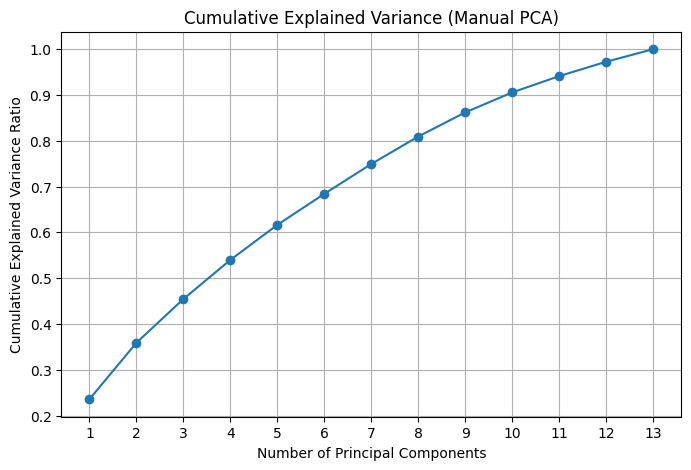

PC1: explained 0.2356, cumulative 0.2356
PC2: explained 0.1233, cumulative 0.3589
PC3: explained 0.0955, cumulative 0.4544
PC4: explained 0.0854, cumulative 0.5398
PC5: explained 0.0765, cumulative 0.6164
PC6: explained 0.0677, cumulative 0.6841
PC7: explained 0.0652, cumulative 0.7493
PC8: explained 0.0600, cumulative 0.8093
PC9: explained 0.0527, cumulative 0.8620
PC10: explained 0.0437, cumulative 0.9056


In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance (Manual PCA)")
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance)+1))
plt.show()

# Show numeric values for first few PCs
for i in range(min(10, len(explained_variance_ratio))):
    print(f"PC{i+1}: explained {explained_variance_ratio[i]:.4f}, cumulative {cumulative_variance[i]:.4f}")


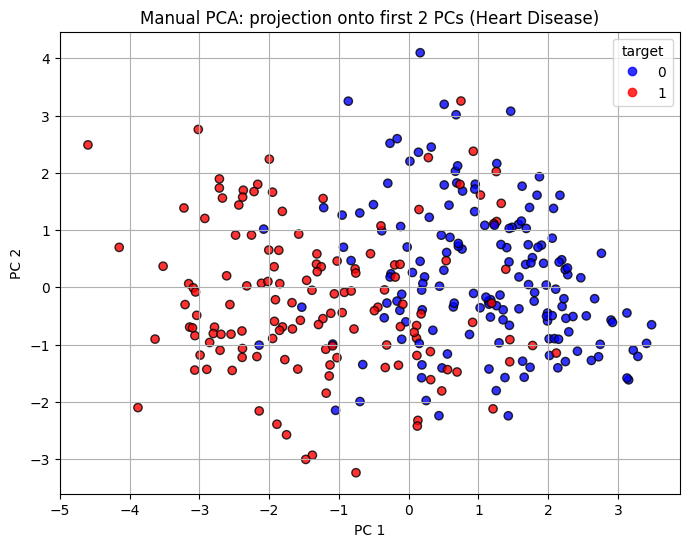

In [30]:
k = 10
W = sorted_eigenvectors[:, :k]  # shape: (n_features, k)
X_pca_manual = X_standardized.dot(W)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_manual[:,0], X_pca_manual[:,1], c=y, cmap='bwr', alpha=0.8, edgecolors='k')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Manual PCA: projection onto first 2 PCs (Heart Disease)")
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="target")
plt.show()

## **with builtin**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [25]:
X = data.drop('condition', axis=1).values
y = data['condition'].values

# Standardize using sklearn (safer numerically)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape after standardization:", X_scaled.shape)


Shape after standardization: (297, 13)


In [32]:
# Fit PCA model
pca = PCA()
X_pca_builtin = pca.fit_transform(X_scaled)

print("PCA fitted successfully!")
print("Total components:", pca.n_components_)


PCA fitted successfully!
Total components: 13


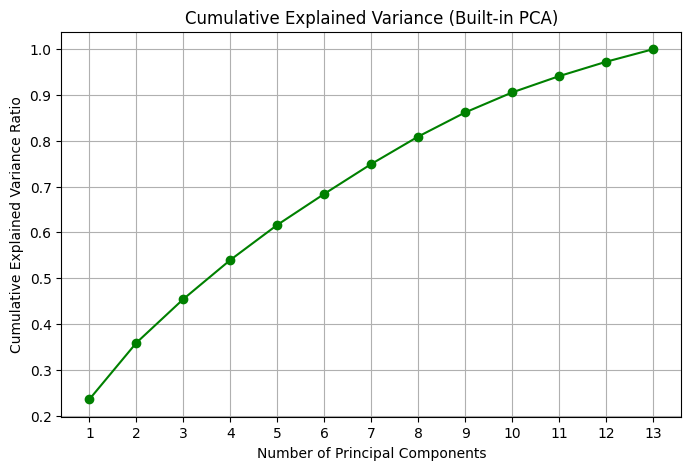

PC1: 0.2356 (cumulative: 0.2356)
PC2: 0.1233 (cumulative: 0.3589)
PC3: 0.0955 (cumulative: 0.4544)
PC4: 0.0854 (cumulative: 0.5398)
PC5: 0.0765 (cumulative: 0.6164)
PC6: 0.0677 (cumulative: 0.6841)
PC7: 0.0652 (cumulative: 0.7493)
PC8: 0.0600 (cumulative: 0.8093)
PC9: 0.0527 (cumulative: 0.8620)
PC10: 0.0437 (cumulative: 0.9056)


In [27]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='green')
plt.title("Cumulative Explained Variance (Built-in PCA)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance)+1))
plt.show()

# Display explained variance ratios
for i, val in enumerate(explained_variance_ratio[:10]):
    print(f"PC{i+1}: {val:.4f} (cumulative: {cumulative_variance[i]:.4f})")


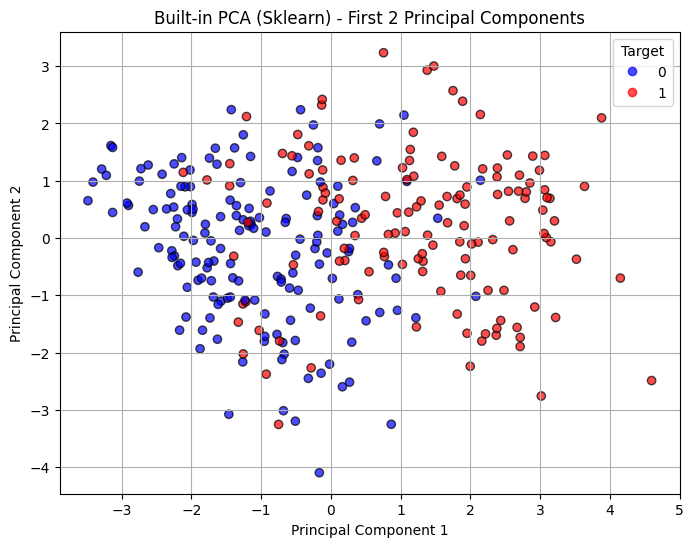

In [28]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_builtin[:,0], X_pca_builtin[:,1],
                      c=y, cmap='bwr', edgecolors='k', alpha=0.7)
plt.title("Built-in PCA (Sklearn) - First 2 Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Target")
plt.grid(True)
plt.show()


comparision

In [31]:
# Assuming X_pca_manual is from manual PCA
from scipy.stats import pearsonr

print("Correlation between first 10 PCs (manual vs built-in):")
for i in range(10):
    corr, _ = pearsonr(X_pca_manual[:, i], X_pca_builtin[:, i])
    print(f"PC{i+1}: correlation = {corr:.4f}")

Correlation between first 10 PCs (manual vs built-in):
PC1: correlation = -1.0000
PC2: correlation = -1.0000
PC3: correlation = 1.0000
PC4: correlation = 1.0000
PC5: correlation = 1.0000
PC6: correlation = -1.0000
PC7: correlation = -1.0000
PC8: correlation = -1.0000
PC9: correlation = 1.0000
PC10: correlation = 1.0000



# **b) Implement linear SVM for any suitable dataset and plot the hyperplane for classification**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [35]:
# Use the same Heart Disease dataset you already loaded
X = data.drop('condition', axis=1).values
y = data['condition'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA transformation done. Shape:", X_pca.shape)


PCA transformation done. Shape: (297, 2)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)


In [37]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

# Evaluate
print(" Model trained successfully!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


 Model trained successfully!
Accuracy: 0.8111111111111111

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82        48
           1       0.80      0.79      0.80        42

    accuracy                           0.81        90
   macro avg       0.81      0.81      0.81        90
weighted avg       0.81      0.81      0.81        90



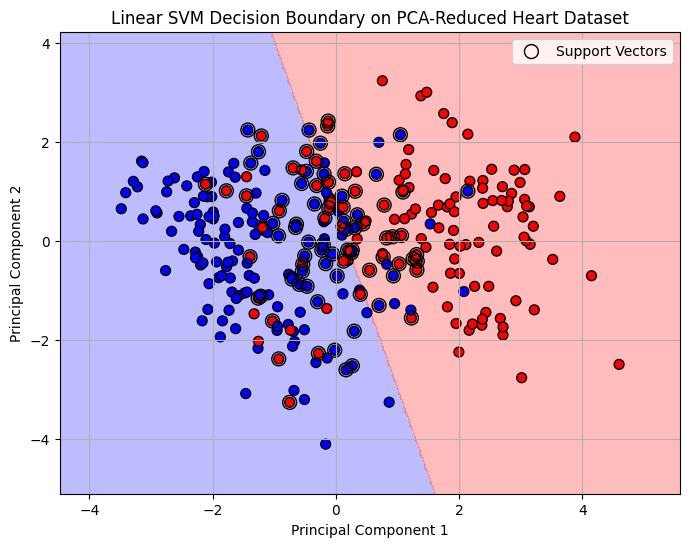

In [38]:
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='bwr', edgecolors='k', s=50)
plt.title("Linear SVM Decision Boundary on PCA-Reduced Heart Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.scatter(svm_model.support_vectors_[:, 0],
            svm_model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='black', label='Support Vectors')

plt.legend()
plt.grid(True)
plt.show()
